In [41]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("D:/Data science/AV2-2BIM/netflix.csv")

In [42]:
#Passo 1
print(df.head())
print(df.info())
print(df.describe())

             titulo    genero           pais    idioma duracao classificacao  \
0   Stranger Things     Drama             UK   Coreano  69 min             R   
1      Quantum Love     Crime         France  Espanhol  54 min         TV-14   
2    Midnight Heist  Thriller  United States   Coreano  55 min         TV-14   
3       Red Horizon    Sci-Fi        Germany     Hindi  28 min         TV-PG   
4  Lost Frequencies     Crime    South Korea   Coreano  40 min             R   

  data_lancamento  nota_imdb  mulheres_assistiram  homens_assistiram  
0      2013-07-23        7.0                  NaN            16067.0  
1      2013-02-01        5.1              20708.0            26548.0  
2      2010-05-15        6.6              49798.0                NaN  
3      2018-11-28        9.1                  NaN            47312.0  
4      2022-04-05        4.2              10191.0            39497.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 1

In [43]:
#Passo 2 - anilisar quantos nulos temos
print(df.isnull().sum())

titulo                  0
genero                  0
pais                    0
idioma                  0
duracao                 6
classificacao          14
data_lancamento         0
nota_imdb               6
mulheres_assistiram    14
homens_assistiram      21
dtype: int64


In [44]:
#Passo 2 - calcular as médias
media_duracao = df['duracao'].str.replace(' min', '').astype(float).mean()
media_imdb = df['nota_imdb'].mean()
media_mulheres = df['mulheres_assistiram'].mean()
media_homens = df['homens_assistiram'].mean()

In [45]:
#Passo 2 - corrigindo os nulos 
df['duracao'] = df['duracao'].str.replace(' min', '').astype(float) #transformar de string para numero
df['duracao'].fillna(media_duracao , inplace = True)
df['nota_imdb'].fillna(media_imdb , inplace = True)
df['mulheres_assistiram'].fillna(media_mulheres , inplace = True)
df['homens_assistiram'].fillna(media_homens , inplace = True)
df = df.dropna(subset=['classificacao'])
print(df.head(10))
print(df.isnull().sum())

                 titulo    genero           pais     idioma  duracao  \
0       Stranger Things     Drama             UK    Coreano     69.0   
1          Quantum Love     Crime         France   Espanhol     54.0   
2        Midnight Heist  Thriller  United States    Coreano     55.0   
3           Red Horizon    Sci-Fi        Germany      Hindi     28.0   
4      Lost Frequencies     Crime    South Korea    Coreano     40.0   
5              Deep Web    Comedy  United States      Hindi     56.0   
6         The Iron Pact    Comedy  United States    Francês    127.0   
7            CyberStorm     Drama             UK  Português     34.0   
8       Stranger Things    Sci-Fi          Spain    Coreano     23.0   
9  The Forgotten Island     Crime    South Korea     Inglês     15.0   

  classificacao data_lancamento  nota_imdb  mulheres_assistiram  \
0             R      2013-07-23        7.0         24372.231183   
1         TV-14      2013-02-01        5.1         20708.000000   
2     

C:\Users\Marcelo H\AppData\Local\Temp\ipykernel_7408\1418268566.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duracao'].fillna(media_duracao , inplace = True)
C:\Users\Marcelo H\AppData\Local\Temp\ipykernel_7408\1418268566.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [46]:
#Passo 3 - padronizando os paises
print(df['pais'].unique())
substituicoes_paises = {
    'UK': 'United Kingdom',
    'U.S.': 'USA',
    'United States': 'USA',
    'South Korea': 'South Korea',  # já está OK
    'USA': 'USA',                  # já está OK
    'Brazil': 'Brazil',            # já está OK
    'France': 'France',            # já está OK
    'Germany': 'Germany',          # já está OK
    'Spain': 'Spain',              # já está OK
    'Japan': 'Japan',              # já está OK
    'India': 'India'               # já está OK
}
df['pais'] = df['pais'].replace(substituicoes_paises)
print(df['pais'].unique())

['UK' 'France' 'United States' 'Germany' 'South Korea' 'Spain' 'U.S.'
 'Japan' 'USA' 'Brazil' 'India']
['United Kingdom' 'France' 'USA' 'Germany' 'South Korea' 'Spain' 'Japan'
 'Brazil' 'India']


In [47]:
#Passo 4 - Definindo o público predominante
df['publico_predominante'] = df.apply(
    lambda row: 'Mulheres' if row['mulheres_assistiram'] > row['homens_assistiram'] 
    else ('Homens' if row['homens_assistiram'] > row['mulheres_assistiram'] else 'Empate'),
    axis=1)

In [48]:
#Passo 4 - extrindo o ano e o mes
df['data_lancamento'] = pd.to_datetime(df['data_lancamento'], errors = 'coerce')
df['ano_lancamento'] = df['data_lancamento'].dt.year
df['mes_lancamento'] = df['data_lancamento'].dt.month

In [49]:
#Passo 5 - top 5 filmes mais assistidos
df['total_espectadores'] = df['mulheres_assistiram'] + df['homens_assistiram']
top_5_filmes = df.sort_values(by='total_espectadores', ascending=False).head(5)
print(top_5_filmes[['titulo', 'total_espectadores']])

              titulo  total_espectadores
30     The Iron Pact             96949.0
39  Beyond the Stars             90845.0
21  La Casa de Papel             88586.0
57  City of Whispers             88018.0
46     The Iron Pact             86601.0


In [50]:
#Passo 5 - top 3 generos com a maior média de nota IMDB
generos_top_imdb = df.groupby('genero')['nota_imdb'].mean().sort_values(ascending=False).head(3)
print(generos_top_imdb)

genero
Action    6.842841
Drama     6.838087
Comedy    6.799399
Name: nota_imdb, dtype: float64


ano_lancamento
2010    11
2011    10
2012    16
2013    16
2014    10
2015    11
2016    15
2017    16
2018    19
2019    12
2020    15
2021    22
2022    13
Name: count, dtype: int64


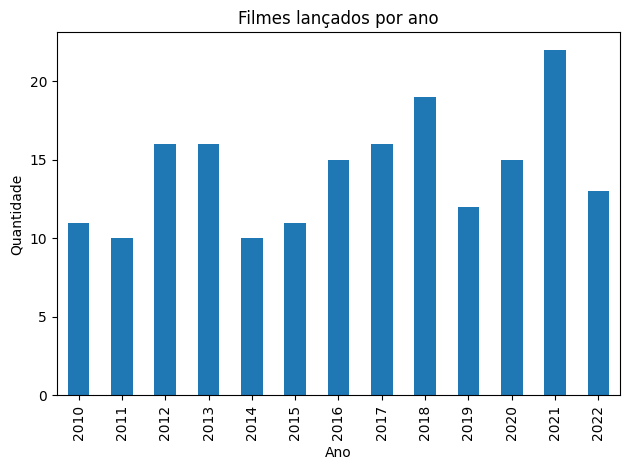

In [51]:
#Passo 5 - filmes lançados por ano
lancamentos_por_ano = df['ano_lancamento'].value_counts().sort_index()
print(lancamentos_por_ano)
lancamentos_por_ano.plot(kind='bar', title='Filmes lançados por ano', xlabel='Ano', ylabel='Quantidade')
plt.tight_layout()
plt.show()

In [52]:
#Passo 5 - idioma mais comun
idioma_mais_comum = df['idioma'].mode()[0]
print("Idioma mais comum:", idioma_mais_comum)

Idioma mais comum: Hindi


In [53]:
#Passo 6 - Relação entre genero e classificação
tabela_generoxclassificacao = pd.crosstab(df['genero'], df['classificacao'])
print("Gênero X Classificação")
print(tabela_generoxclassificacao)

Gênero X Classificação
classificacao  G  PG  PG-13  R  TV-14  TV-G  TV-MA  TV-PG  TV-Y
genero                                                         
Action         4   1      2  0      4     1      4      2     0
Comedy         2   2      2  5      2     2      4      1     4
Crime          2   4      2  4      3     1      2      5     4
Documentary    2   1      2  2      0     0      1      2     5
Drama          3   3      3  2      1     1      0      1     4
Horror         0   4      1  1      3     1      2      1     2
Romance        2   3      2  0      2     3      5      0     1
Sci-Fi         3   4      6  5      0     1      2      6     2
Thriller       1   0      9  3      3     0      3      0     3


In [54]:
#Passo 6 - crosstab entre público predominante e indioma
tabela_publicoxidioma = pd.crosstab(df['publico_predominante'], df['idioma'])
print("\nPúblico Predominante x Idioma")
print(tabela_publicoxidioma)


Público Predominante x Idioma
idioma                Coreano  Espanhol  Francês  Hindi  Inglês  Japonês  \
publico_predominante                                                       
Homens                      9        12       13     17      15       11   
Mulheres                   19        14       21     18       6       10   

idioma                Português  
publico_predominante             
Homens                        9  
Mulheres                     12  


In [55]:
#Passo 6 - crosstab entre país e classificação
tabela_paisxclassificacao = pd.crosstab(df['pais'], df['classificacao'])
print("\nPaís x Classificação")
print(tabela_paisxclassificacao)


País x Classificação
classificacao   G  PG  PG-13  R  TV-14  TV-G  TV-MA  TV-PG  TV-Y
pais                                                            
Brazil          4   3      2  2      2     0      2      3     2
France          0   0      3  1      4     2      1      1     2
Germany         2   2      1  3      3     2      2      4     3
India           1   1      6  2      1     1      2      0     0
Japan           1   3      1  1      2     0      1      1     1
South Korea     3   3      1  2      2     2      0      1     3
Spain           2   3      3  4      0     1      2      1     0
USA             5   6      7  3      3     1     11      7    12
United Kingdom  1   1      5  4      1     1      2      0     2


In [56]:
#Passo 6 - crosstab entre ano de lançamento e público predominante
tabela_lancamentoxpublico = pd.crosstab(df['ano_lancamento'], df['publico_predominante'])
print("\nAno de lançamento x Público predominante")
print(tabela_lancamentoxpublico)


Ano de lançamento x Público predominante
publico_predominante  Homens  Mulheres
ano_lancamento                        
2010                       3         8
2011                       5         5
2012                       9         7
2013                       8         8
2014                       6         4
2015                       7         4
2016                       7         8
2017                       9         7
2018                       7        12
2019                       6         6
2020                       5        10
2021                       8        14
2022                       6         7


In [57]:
#Passo 7 - adicionando os dummies de classificação no data frame
dummies_classificacao = pd.get_dummies(df['classificacao'], prefix='classificacao')
df = pd.concat([df, dummies_classificacao], axis=1)
print(dummies_classificacao.head())

   classificacao_G  classificacao_PG  classificacao_PG-13  classificacao_R  \
0            False             False                False             True   
1            False             False                False            False   
2            False             False                False            False   
3            False             False                False            False   
4            False             False                False             True   

   classificacao_TV-14  classificacao_TV-G  classificacao_TV-MA  \
0                False               False                False   
1                 True               False                False   
2                 True               False                False   
3                False               False                False   
4                False               False                False   

   classificacao_TV-PG  classificacao_TV-Y  
0                False               False  
1                False               F

In [58]:
#Passo 7 - imapcto na classificação indicativa na nota imdb
media_imdb_16 = df[df['classificacao']==16]['nota_imdb'].mean()
print("Média do IMDB em filmes com classificação indicativa '+16': ", media_imdb_16)
print("Média geral do IMDB': ", media_imdb)

Média do IMDB em filmes com classificação indicativa '+16':  nan
Média geral do IMDB':  6.585567010309278


tema_emocional
False    169
True      17
Name: count, dtype: int64


C:\Users\Marcelo H\AppData\Local\Temp\ipykernel_7408\3684786348.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['tema_emocional'] = df['titulo'].str.contains(palavras_chave, flags=re.IGNORECASE, regex=True)


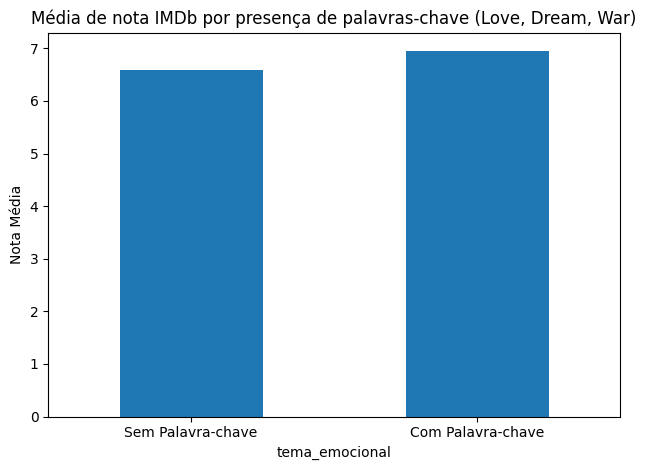

In [59]:
#Passo 8 - identificando os temas emocionais DREAM/LOVE/ WAR
import re
palavras_chave = r'\b(Love|Dream|War)\b'
df['tema_emocional'] = df['titulo'].str.contains(palavras_chave, flags=re.IGNORECASE, regex=True)
print(df['tema_emocional'].value_counts())
df.groupby('tema_emocional')['nota_imdb'].mean().plot(
    kind='bar',
    title='Média de nota IMDb por presença de palavras-chave (Love, Dream, War)',
    ylabel='Nota Média'
)
plt.xticks([0, 1], ['Sem Palavra-chave', 'Com Palavra-chave'], rotation=0)
plt.tight_layout()
plt.show()

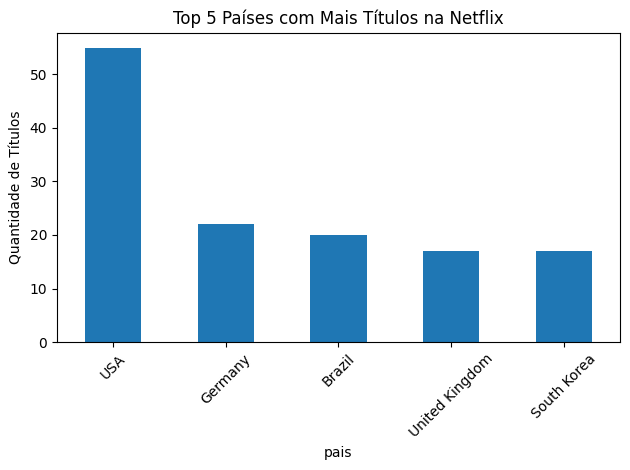

In [60]:
#Passo 9 - Gráfico de barras dos 5 países com mais títulos
df['pais'].value_counts().head(5).plot(
    kind='bar',
    title='Top 5 Países com Mais Títulos na Netflix',
    ylabel='Quantidade de Títulos'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


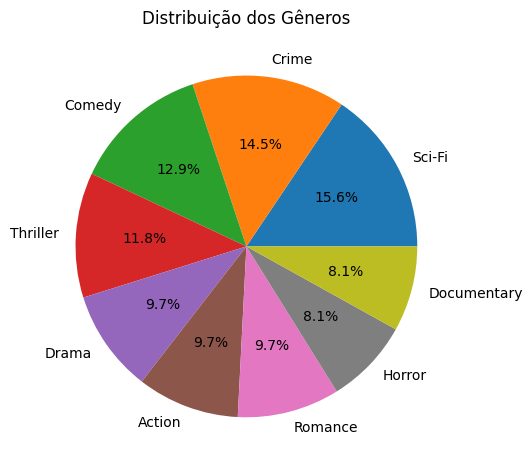

In [61]:
#Passo 9 - Gráfico de pizza da distribuição dos gêneros
df['genero'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribuição dos Gêneros',
    ylabel=''
)
plt.tight_layout()
plt.show()

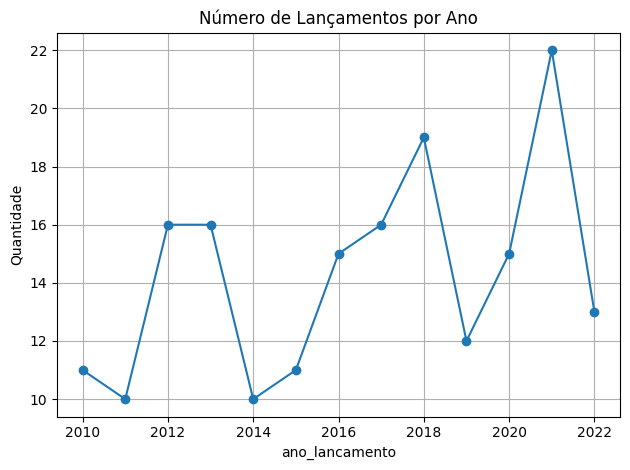

In [62]:
#Passo 9 - Gráfico de linha com lançamentos por ano
df['ano_lancamento'].value_counts().sort_index().plot(
    kind='line',
    marker='o',
    title='Número de Lançamentos por Ano',
    ylabel='Quantidade'
)
plt.grid(True)
plt.tight_layout()
plt.show()

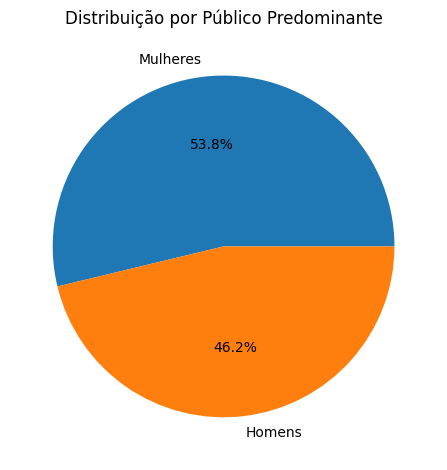

In [63]:
#Passo 9 -  Gráfico de Pizza da Distribuição por Público Predominante
df['publico_predominante'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribuição por Público Predominante',
    ylabel=''
)
plt.tight_layout()
plt.show()